In [ ]:
%pip install seaborn

In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Connect to our Kalimati SQLite database

connection = sqlite3.connect("kalimati.db")

print("Database connected successfully!")

Database connected successfully!


In [7]:
# Read the prices table directly from SQLite into Pandas

query = """
SELECT
    date,
    commodity,
    unit,
    min,
    max,
    avg
FROM prices
"""

df = pd.read_sql_query(query, connection)

# Convert date from text into Pandas datetime
df["date"] = pd.to_datetime(df["date"])

print("Rows:", len(df))
print("Columns:", df.shape[1])

df.head()

Rows: 21095
Columns: 6


,date,commodity,unit,min,max,avg
0,2026-01-01,अदुवा,के.जी.,60.0,80.0,70.0
1,2026-01-01,अनार,के.जी.,300.0,350.0,325.0
2,2026-01-01,अमला,के.जी,65.0,75.0,70.0
3,2026-01-01,आभोकाडो,के.जी,250.0,350.0,300.0
4,2026-01-01,आलु रातो(भारतीय),के जी,24.0,27.0,25.5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21095 entries, 0 to 21094
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       21095 non-null  datetime64[ns]
 1   commodity  21095 non-null  object        
 2   unit       21095 non-null  object        
 3   min        21095 non-null  float64       
 4   max        21095 non-null  float64       
 5   avg        21095 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 989.0+ KB


In [9]:
df.describe()

,date,min,max,avg
count,21095,21095.000000,21095.000000,21095.000000
mean,2026-04-14 08:08:16.951884032,131.150794,154.819957,142.965415
min,2026-01-01 00:00:00,5.000000,8.000000,6.670000
25%,2026-02-20 00:00:00,42.000000,57.000000,50.000000
50%,2026-04-12 00:00:00,80.000000,90.000000,85.000000
75%,2026-06-07 00:00:00,170.000000,200.000000,180.000000
max,2026-07-31 00:00:00,2200.000000,2400.000000,2300.000000
std,NaN,147.327432,174.226083,160.497421


In [10]:
df.isnull().sum()

date         0
commodity    0
unit         0
min          0
max          0
avg          0
dtype: int64

In [11]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("Number of commodities:",
      df["commodity"].nunique())

Start date: 2026-01-01 00:00:00
End date: 2026-07-31 00:00:00
Number of commodities: 136


In [12]:
basket_items = [
    "आलु रातो(लाम्चो)",
    "प्याज सुकेको (भारतीय)",
    "गोलभेडा ठूलो(नेपाली)",
    "काउली तराई",
    "बन्दा(लोकल)",
    "गाजर(तराई)",
    "काक्रो(लोकल)",
    "भिण्डी",
    "लौका",
    "मूला सेतो(लोकल)"
]

In [13]:
# Check which basket items actually exist in our dataset

for item in basket_items:
    if item in df["commodity"].values:
        print("✓", item)
    else:
        print("✗ NOT FOUND:", item)

✓ आलु रातो(लाम्चो)
✓ प्याज सुकेको (भारतीय)
✓ गोलभेडा ठूलो(नेपाली)
✓ काउली तराई
✓ बन्दा(लोकल)
✓ गाजर(तराई)
✓ काक्रो(लोकल)
✓ भिण्डी
✓ लौका
✓ मूला सेतो(लोकल)


In [14]:
basket_df = df[
    df["commodity"].isin(basket_items)
].copy()

coverage = (
    basket_df
    .groupby("commodity")["date"]
    .nunique()
    .sort_values(ascending=False)
)

coverage

commodity
आलु रातो(लाम्चो)         210
काक्रो(लोकल)             210
बन्दा(लोकल)              210
प्याज सुकेको (भारतीय)    210
लौका                     209
भिण्डी                   209
गाजर(तराई)               156
मूला सेतो(लोकल)          111
काउली तराई                95
गोलभेडा ठूलो(नेपाली)      85
Name: date, dtype: int64

In [15]:
# ======================================================
# CALCULATE DAILY BASKET PRICE
# ======================================================

# Keep only the selected basket commodities
basket_df = df[
    df["commodity"].isin(basket_items)
].copy()

# Calculate the average price of the basket for each day
daily_basket = (
    basket_df
    .groupby("date")
    .agg(
        Basket_Price=("avg", "mean"),
        Items_Available=("commodity", "nunique")
    )
    .reset_index()
)

# Round the basket price
daily_basket["Basket_Price"] = daily_basket["Basket_Price"].round(2)

daily_basket.head(10)

,date,Basket_Price,Items_Available
0,2026-01-01,61.26,10
1,2026-01-02,63.74,10
2,2026-01-03,64.67,9
3,2026-01-04,62.56,9
4,2026-01-05,61.63,10
5,2026-01-06,62.56,10
6,2026-01-07,64.74,10
7,2026-01-08,64.53,10
8,2026-01-09,66.81,10
9,2026-01-10,68.86,10


In [16]:
# ======================================================
# CALCULATE BASKET PRICE INDEX
# ======================================================

# Use the first available day's basket price as the base
base_price = daily_basket["Basket_Price"].iloc[0]

print("Base basket price:", base_price)

# Calculate the index
daily_basket["Basket_Index"] = (
    daily_basket["Basket_Price"] / base_price
) * 100

# Round the index
daily_basket["Basket_Index"] = (
    daily_basket["Basket_Index"].round(2)
)

# Display the result
daily_basket.head(10)

Base basket price: 61.26


,date,Basket_Price,Items_Available,Basket_Index
0,2026-01-01,61.26,10,100.00
1,2026-01-02,63.74,10,104.05
2,2026-01-03,64.67,9,105.57
3,2026-01-04,62.56,9,102.12
4,2026-01-05,61.63,10,100.60
5,2026-01-06,62.56,10,102.12
6,2026-01-07,64.74,10,105.68
7,2026-01-08,64.53,10,105.34
8,2026-01-09,66.81,10,109.06
9,2026-01-10,68.86,10,112.41


In [17]:
daily_basket[
    ["date", "Basket_Price", "Items_Available", "Basket_Index"]
].tail(10)
print("Minimum index:", daily_basket["Basket_Index"].min())
print("Maximum index:", daily_basket["Basket_Index"].max())
print("Latest index:", daily_basket["Basket_Index"].iloc[-1])

Minimum index: 47.13
Maximum index: 119.18
Latest index: 76.61


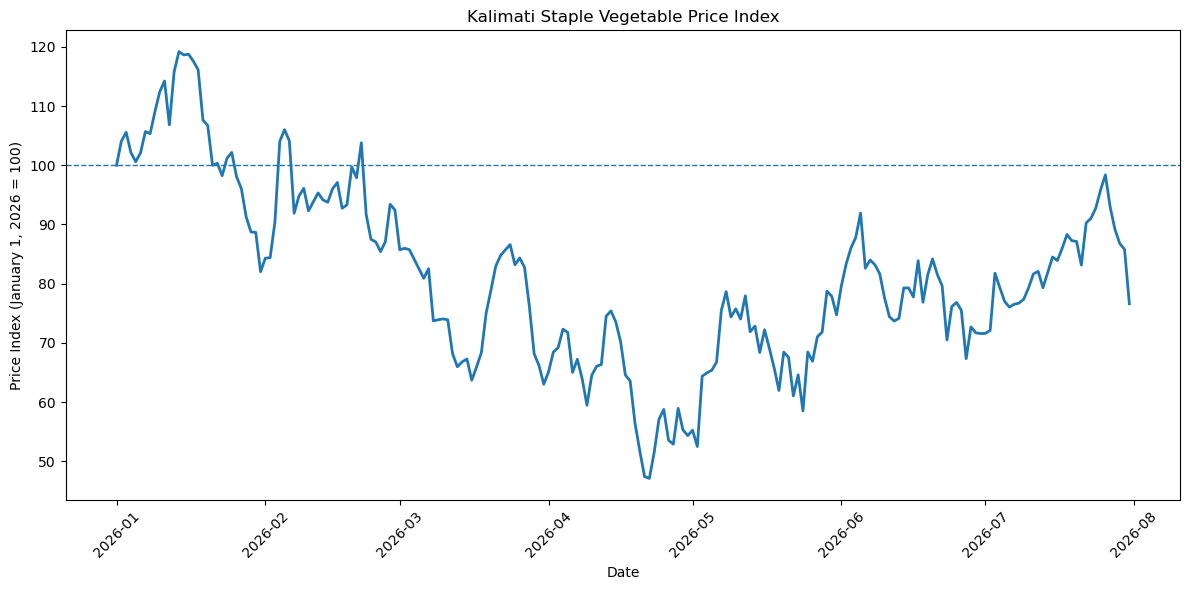

In [18]:
# ======================================================
# BASKET PRICE INDEX — TREND CHART
# ======================================================

plt.figure(figsize=(12, 6))

plt.plot(
    daily_basket["date"],
    daily_basket["Basket_Index"],
    linewidth=2
)

# Base-period reference line
plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Kalimati Staple Vegetable Price Index"
)

plt.xlabel("Date")
plt.ylabel("Price Index (January 1, 2026 = 100)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [19]:
# ======================================================
# SEASONALITY ANALYSIS
# ======================================================

# Create month number
df["month"] = df["date"].dt.month

# Create readable month name
df["month_name"] = df["date"].dt.strftime("%B")

# Check the result
df[["date", "month", "month_name"]].head()

,date,month,month_name
0,2026-01-01,1,January
1,2026-01-01,1,January
2,2026-01-01,1,January
3,2026-01-01,1,January
4,2026-01-01,1,January


In [20]:
# Calculate average price of each commodity for each month

monthly_prices = (
    df.groupby(["commodity", "month", "month_name"])["avg"]
    .mean()
    .reset_index()
)

monthly_prices["avg"] = monthly_prices["avg"].round(2)

monthly_prices.head(10)

,commodity,month,month_name,avg
0,अंगुर(कालो),2,February,382.38
1,अंगुर(कालो),3,March,322.41
2,अंगुर(कालो),4,April,347.42
3,अंगुर(कालो),5,May,416.32
4,अंगुर(हरियो),1,January,210.00
5,अंगुर(हरियो),2,February,231.96
6,अंगुर(हरियो),3,March,206.25
7,अंगुर(हरियो),4,April,220.50
8,अंगुर(हरियो),5,May,274.62
9,अदुवा,1,January,89.64


In [21]:
# Find the highest-priced commodity in each month

monthly_highest = (
    monthly_prices
    .sort_values(["month", "avg"], ascending=[True, False])
    .groupby("month")
    .first()
    .reset_index()
)

monthly_highest[
    ["month", "month_name", "commodity", "avg"]
]

,month,month_name,commodity,avg
0,1,January,कुरीलो,1966.67
1,2,February,सिताके च्याउ,900.45
2,3,March,माछा सुकेको,900.00
3,4,April,माछा सुकेको,900.00
4,5,May,सिताके च्याउ,898.92
5,6,June,सिताके च्याउ,900.00
6,7,July,सिताके च्याउ,898.39


In [22]:
# ======================================================
# COMMODITY × MONTH HEATMAP
# ======================================================

# Create a table:
# rows    = commodities
# columns = months
# values  = average price

heatmap_data = monthly_prices.pivot(
    index="commodity",
    columns="month_name",
    values="avg"
)

# Keep months in chronological order
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July"
]

heatmap_data = heatmap_data.reindex(
    columns=month_order
)

heatmap_data.head()

month_name,January,February,March,April,May,June,July
commodity,,,,,,,
अंगुर(कालो),NaN,382.38,322.41,347.42,416.32,NaN,NaN
अंगुर(हरियो),210.00,231.96,206.25,220.50,274.62,NaN,NaN
अदुवा,89.64,108.36,102.21,85.08,127.17,134.17,191.91
अनार,325.15,313.99,317.76,366.17,435.00,412.03,466.91
अमला,78.39,97.25,133.62,182.22,NaN,NaN,266.43


In [23]:
import matplotlib.font_manager as fm

fonts = fm.findSystemFonts()

for font in fonts:
    if "NotoSansDevanagari" in font or "Noto" in font:
        print(font)

In [24]:
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if any(x in font.lower() for x in ["devanagari", "mangal", "nirmala", "kokila"]):
        print(font)

C:\Windows\Fonts\Nirmala.ttc


c:\Users\ANUP\.conda\envs\floodml\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\ANUP\.conda\envs\floodml\lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
c:\Users\ANUP\.conda\envs\floodml\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\ANUP\.conda\envs\floodml\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\ANUP\.conda\envs\floodml\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\ANUP\.conda\envs\floodml\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTE

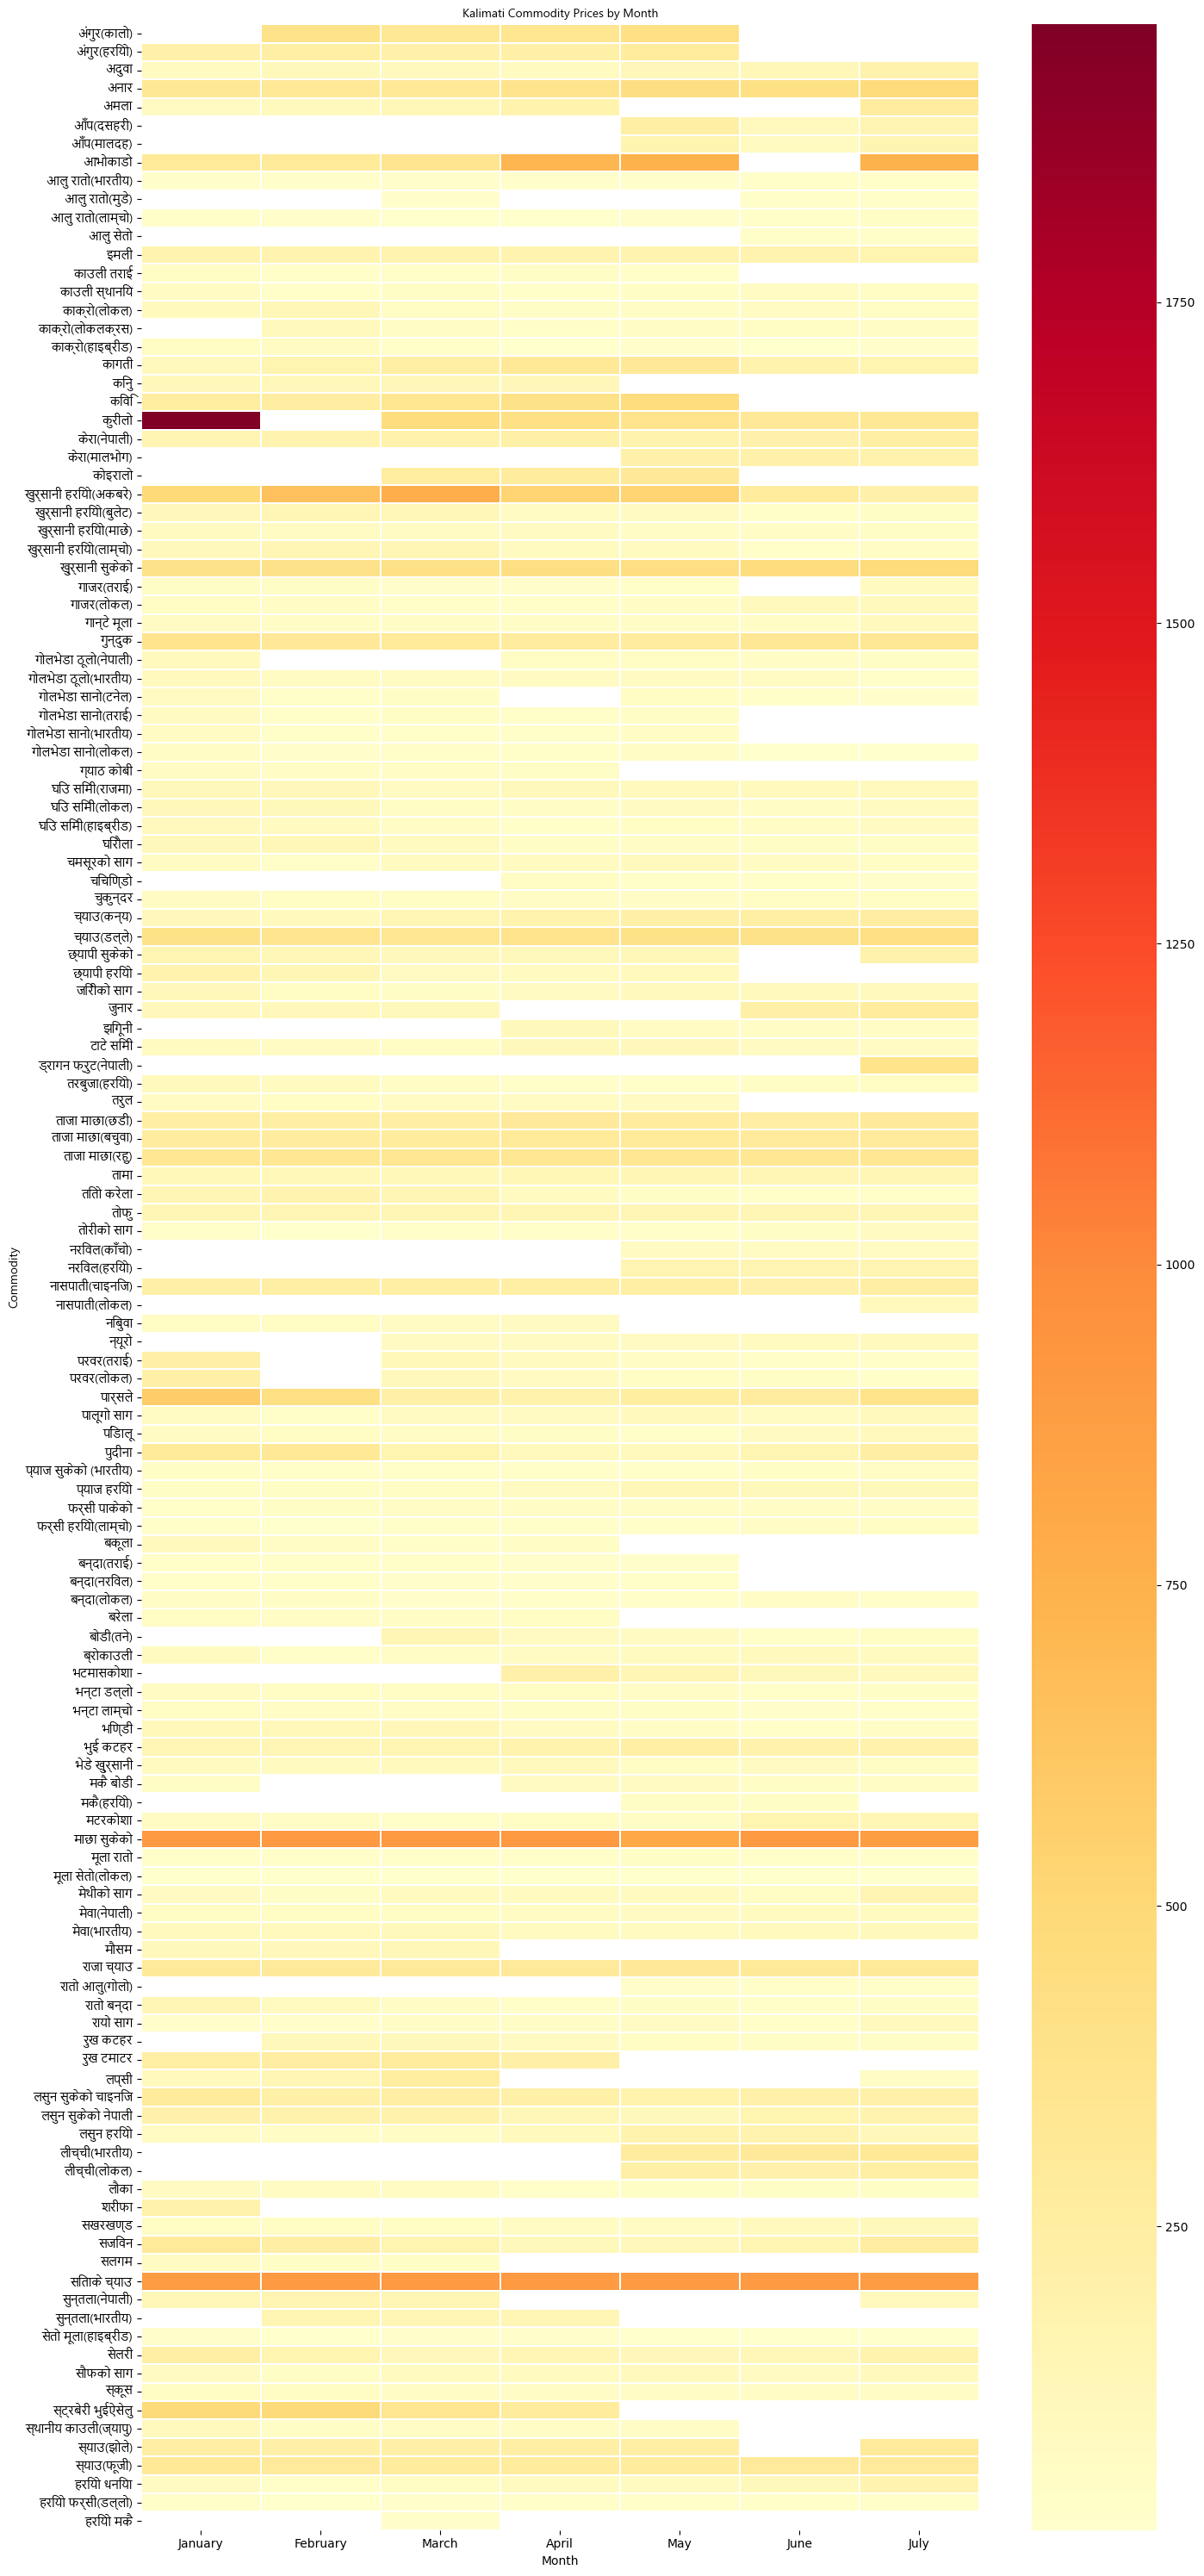

In [25]:
# ======================================================
# COMMODITY × MONTH HEATMAP
# ======================================================

from matplotlib import font_manager
import matplotlib.pyplot as plt
import seaborn as sns

# Windows Devanagari font
font_path = r"C:\Windows\Fonts\Nirmala.ttc"

# Create font properties
nepali_font = font_manager.FontProperties(fname=font_path)

plt.figure(figsize=(14, 30))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3
)

# Apply Nepali font to Y-axis commodity names
plt.yticks(
    fontproperties=nepali_font,
    rotation=0
)

plt.title(
    "Kalimati Commodity Prices by Month",
    fontproperties=nepali_font
)

plt.xlabel("Month")
plt.ylabel(
    "Commodity",
    fontproperties=nepali_font
)

plt.tight_layout()
plt.show()

In [26]:
# ======================================================
# MONTHLY PRICE TREND — BASKET COMMODITIES
# ======================================================

# Keep only our selected basket commodities
basket_monthly = monthly_prices[
    monthly_prices["commodity"].isin(basket_items)
].copy()

# Arrange months in chronological order
basket_monthly["month"] = pd.Categorical(
    basket_monthly["month_name"],
    categories=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July"
    ],
    ordered=True
)

# Sort the data
basket_monthly = basket_monthly.sort_values(
    ["commodity", "month"]
)

basket_monthly.head(20)

,commodity,month,month_name,avg
50,आलु रातो(लाम्चो),January,January,28.94
51,आलु रातो(लाम्चो),February,February,25.77
52,आलु रातो(लाम्चो),March,March,19.93
53,आलु रातो(लाम्चो),April,April,20.75
54,आलु रातो(लाम्चो),May,May,27.25
55,आलु रातो(लाम्चो),June,June,35.99
56,आलु रातो(लाम्चो),July,July,44.75
66,काउली तराई,January,January,64.55
67,काउली तराई,February,February,31.49
68,काउली तराई,March,March,40.71


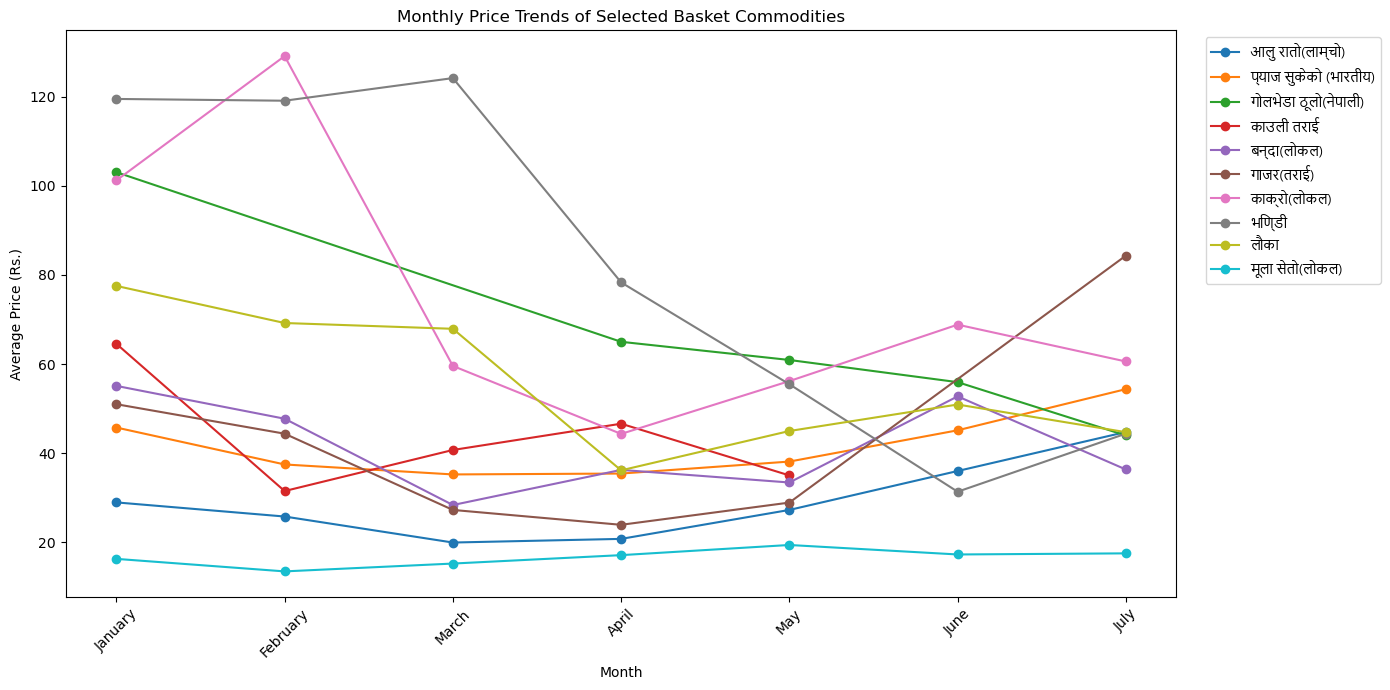

In [28]:
# ======================================================
# MONTHLY PRICE TREND CHART
# ======================================================

from matplotlib import font_manager

# Windows font that supports Nepali / Devanagari
font_path = r"C:\Windows\Fonts\Nirmala.ttc"

nepali_font = font_manager.FontProperties(
    fname=font_path,
    size=10
)

plt.figure(figsize=(14, 7))

for commodity in basket_items:

    commodity_data = basket_monthly[
        basket_monthly["commodity"] == commodity
    ]

    plt.plot(
        commodity_data["month_name"],
        commodity_data["avg"],
        marker="o",
        label=commodity
    )

plt.title(
    "Monthly Price Trends of Selected Basket Commodities"
)

plt.xlabel("Month")
plt.ylabel("Average Price (Rs.)")

plt.xticks(rotation=45)

# Get legend and apply Nepali font
legend = plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    prop=nepali_font
)

plt.tight_layout()
plt.show()

In [29]:
# ======================================================
# NORMALIZED COMMODITY PRICE INDEX
# ======================================================

# Make a copy so we don't modify the original data
normalized_prices = basket_monthly.copy()

# Find each commodity's first available monthly price
base_prices = (
    normalized_prices
    .groupby("commodity")["avg"]
    .transform("first")
)

# Convert prices into a 100-based index
normalized_prices["Price_Index"] = (
    normalized_prices["avg"] / base_prices
) * 100

# Round for readability
normalized_prices["Price_Index"] = (
    normalized_prices["Price_Index"].round(2)
)

normalized_prices.head(20)

,commodity,month,month_name,avg,Price_Index
50,आलु रातो(लाम्चो),January,January,28.94,100.00
51,आलु रातो(लाम्चो),February,February,25.77,89.05
52,आलु रातो(लाम्चो),March,March,19.93,68.87
53,आलु रातो(लाम्चो),April,April,20.75,71.70
54,आलु रातो(लाम्चो),May,May,27.25,94.16
55,आलु रातो(लाम्चो),June,June,35.99,124.36
56,आलु रातो(लाम्चो),July,July,44.75,154.63
66,काउली तराई,January,January,64.55,100.00
67,काउली तराई,February,February,31.49,48.78
68,काउली तराई,March,March,40.71,63.07


In [30]:
normalized_prices[
    ["commodity", "month_name", "avg", "Price_Index"]
].head(20)

,commodity,month_name,avg,Price_Index
50,आलु रातो(लाम्चो),January,28.94,100.00
51,आलु रातो(लाम्चो),February,25.77,89.05
52,आलु रातो(लाम्चो),March,19.93,68.87
53,आलु रातो(लाम्चो),April,20.75,71.70
54,आलु रातो(लाम्चो),May,27.25,94.16
55,आलु रातो(लाम्चो),June,35.99,124.36
56,आलु रातो(लाम्चो),July,44.75,154.63
66,काउली तराई,January,64.55,100.00
67,काउली तराई,February,31.49,48.78
68,काउली तराई,March,40.71,63.07


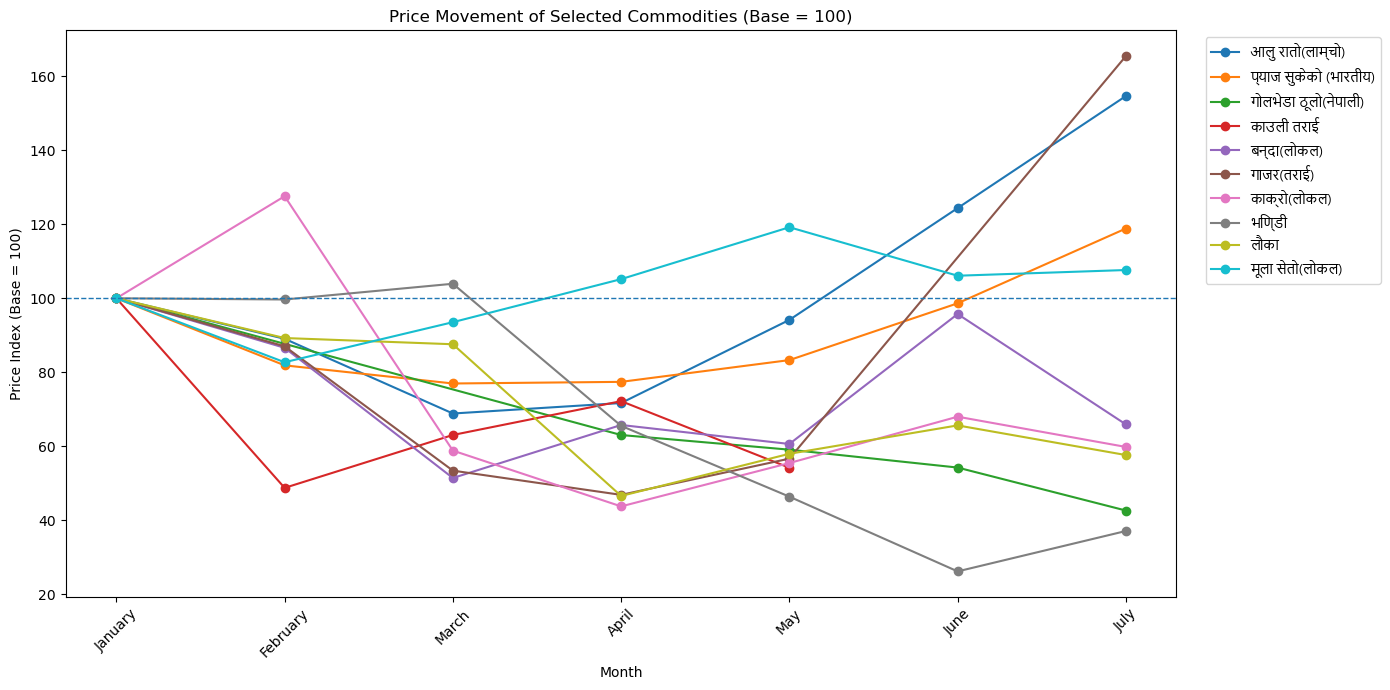

In [31]:
# ======================================================
# NORMALIZED PRICE INDEX CHART
# ======================================================

plt.figure(figsize=(14, 7))

for commodity in basket_items:

    commodity_data = normalized_prices[
        normalized_prices["commodity"] == commodity
    ]

    plt.plot(
        commodity_data["month_name"],
        commodity_data["Price_Index"],
        marker="o",
        label=commodity
    )

# Reference line: no change from base
plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Price Movement of Selected Commodities (Base = 100)"
)

plt.xlabel("Month")
plt.ylabel("Price Index (Base = 100)")

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    prop=nepali_font
)

plt.tight_layout()
plt.show()

In [32]:
# ======================================================
# BIGGEST PRICE MOVEMENTS
# ======================================================

# Get the first and last index for each commodity
price_movement = (
    normalized_prices
    .sort_values(["commodity", "month"])
    .groupby("commodity")
    .agg(
        Starting_Index=("Price_Index", "first"),
        Ending_Index=("Price_Index", "last")
    )
    .reset_index()
)

# Calculate total percentage movement
price_movement["Percent_Change"] = (
    price_movement["Ending_Index"]
    - price_movement["Starting_Index"]
)

price_movement["Percent_Change"] = (
    price_movement["Percent_Change"].round(2)
)

# Sort from largest increase to largest decrease
price_movement = price_movement.sort_values(
    "Percent_Change",
    ascending=False
)

price_movement

,commodity,Starting_Index,Ending_Index,Percent_Change
3,गाजर(तराई),100.0,165.42,65.42
0,आलु रातो(लाम्चो),100.0,154.63,54.63
5,प्याज सुकेको (भारतीय),100.0,118.84,18.84
8,मूला सेतो(लोकल),100.0,107.63,7.63
6,बन्दा(लोकल),100.0,65.93,-34.07
2,काक्रो(लोकल),100.0,59.84,-40.16
9,लौका,100.0,57.65,-42.35
1,काउली तराई,100.0,54.22,-45.78
4,गोलभेडा ठूलो(नेपाली),100.0,42.66,-57.34
7,भिण्डी,100.0,37.13,-62.87


In [33]:
print("TOP PRICE INCREASES")
print("=" * 60)

print(
    price_movement.head(10)
)

print("\nTOP PRICE DECREASES")
print("=" * 60)

print(
    price_movement.tail(10)
)

TOP PRICE INCREASES
               commodity  Starting_Index  Ending_Index  Percent_Change
3             गाजर(तराई)           100.0        165.42           65.42
0       आलु रातो(लाम्चो)           100.0        154.63           54.63
5  प्याज सुकेको (भारतीय)           100.0        118.84           18.84
8        मूला सेतो(लोकल)           100.0        107.63            7.63
6            बन्दा(लोकल)           100.0         65.93          -34.07
2           काक्रो(लोकल)           100.0         59.84          -40.16
9                   लौका           100.0         57.65          -42.35
1             काउली तराई           100.0         54.22          -45.78
4   गोलभेडा ठूलो(नेपाली)           100.0         42.66          -57.34
7                 भिण्डी           100.0         37.13          -62.87

TOP PRICE DECREASES
               commodity  Starting_Index  Ending_Index  Percent_Change
3             गाजर(तराई)           100.0        165.42           65.42
0       आलु रातो(लाम्चो)           1